In [64]:
# NOTE: Portions of this notebook (marked function bodies and plotting logic) were
# written with the assistance of a generative AI model (Claude) and then reviewed/tested
# by the author, in line with the assignment's Generative AI policy.
import cv2
import numpy as np
import random
import math
import heapq
from collections import deque
from matplotlib import pyplot as plt

random.seed(42)

# SYSTEM PARAMETERS

You are free to change the value of these variables for testing, but do not add extra variables here. This entire block will be replaced when marking.

In [121]:
# DO NOT ADD OTHER VARIABLES HERE

# General settings
seed = 24
image_file = "map.png"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

# Task 3 - BFS
bfs_n = 10
bfs_start_node = 3
bfs_end_node = 72

# Task 4 - PRM and Dijkstra
prm_total_nodes_count = 30
prm_connection_radius = 200
prm_start_location = (50,50)
prm_goal_location = (450,450)

# Task 5 - RRT
rrt_max_nodes_count = 500
rrt_step_size = 40
rrt_max_connection_length = 200
rrt_start_location = (50,50)
rrt_goal_location = (450,450)

# DO NOT ADD OTHER VARIABLES HERE

# Preprocessing - Isolate & Crop Maze Square

`image_file` above points at the raw top-down photo of the maze table (frame, floor, tape markers and all). The cell below locates the light-coloured maze board in that photo, straightens it, crops out everything else (floor, tape, cabling), and overwrites `image_file` to point at the cropped result so every task below operates on a clean, maze-only image.

In [66]:
# Corner detection + perspective crop/warp (written with the assistance of Claude)
# The maze rig has four pastel colour strips taped at its four corners (pink,
# orange, yellow, purple). This block finds the centre of each strip and
# warps the photo so those four centres become the exact corners of a square
# output image - i.e. removes the camera's perspective/tilt and any
# background around the rig.

# HSV ranges tuned to the four corner-marker colours on the rig. Pink needs
# two ranges since its hue wraps around the 0/179 boundary in OpenCV's HSV.
CORNER_COLOR_RANGES = {
    "pink":   [((0, 15, 80), (10, 90, 255)), ((150, 15, 80), (179, 90, 255))],
    "orange": [((5, 90, 80), (18, 255, 255))],
    "yellow": [((19, 80, 80), (34, 255, 255))],
    "purple": [((105, 15, 60), (140, 90, 255))],
}


def _find_table_roi(image, pad_frac=0.05):
    """Find the bounding box of the bright maze table/frame so background
    (e.g. the floor around it) is excluded before colour matching. Without
    this, floor/shadow pixels can be mistaken for a corner marker."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (9, 9), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        h, w = image.shape[:2]
        return 0, 0, w, h
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    pad_x, pad_y = int(w * pad_frac), int(h * pad_frac)
    H, W = image.shape[:2]
    x0, y0 = max(0, x - pad_x), max(0, y - pad_y)
    x1, y1 = min(W, x + w + pad_x), min(H, y + h + pad_y)
    return x0, y0, x1, y1


def _largest_blob_centroid(mask, min_area=150):
    """Centroid (x, y) of the largest connected component in a binary mask."""
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    num, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num <= 1:
        return None
    best = max(range(1, num), key=lambda i: stats[i, cv2.CC_STAT_AREA])
    if stats[best, cv2.CC_STAT_AREA] < min_area:
        return None
    return tuple(centroids[best])


def find_corner_markers(image, color_ranges=CORNER_COLOR_RANGES, min_area=150, restrict_to_table=True):
    """Locate the centre of each coloured corner marker.
    Returns {colour_name: (x, y)} in the original image's pixel coordinates."""
    if restrict_to_table:
        x0, y0, x1, y1 = _find_table_roi(image)
        roi = image[y0:y1, x0:x1]
    else:
        x0, y0 = 0, 0
        roi = image

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    centers = {}
    for name, ranges in color_ranges.items():
        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
        for lower, upper in ranges:
            mask |= cv2.inRange(hsv, np.array(lower), np.array(upper))
        centroid = _largest_blob_centroid(mask, min_area=min_area)
        if centroid is not None:
            centers[name] = (centroid[0] + x0, centroid[1] + y0)
    return centers


def order_points(pts):
    """Sort 4 (x, y) points into [top-left, top-right, bottom-right, bottom-left]
    order, regardless of which colour marker each point came from."""
    pts = np.array(pts, dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(diff)]
    bottom_left = pts[np.argmax(diff)]
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")


def warp_maze(image, color_ranges=CORNER_COLOR_RANGES, output_size=900, margin=1000, min_area=150):
    """Crop/warp `image` so the centres of the four coloured corner markers
    map to a square inset by `margin` pixels from the edge of an
    `output_size` x `output_size` image. The margin keeps the maze
    container's actual border (and the colour markers themselves) visible
    in the output instead of sitting exactly on the image edge."""
    centers = find_corner_markers(image, color_ranges, min_area=min_area)
    if len(centers) != 4:
        missing = set(color_ranges) - set(centers)
        raise ValueError(f"Could not find all 4 corner markers, missing: {missing} (found: {centers})")

    src_pts = order_points(list(centers.values()))
    dst_pts = np.array([
        [margin, margin],
        [output_size - 1 - margin, margin],
        [output_size - 1 - margin, output_size - 1 - margin],
        [margin, output_size - 1 - margin],
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(image, M, (output_size, output_size))
    return warped


def load_and_crop_image(path, output_size=600, margin=50):
    """Read an image file and return it perspective-cropped to the maze corners."""
    raw = cv2.imread(path)
    return warp_maze(raw, output_size=output_size, margin=margin)


# Task 1 - OCCUPANCY MAP (4 marks total)

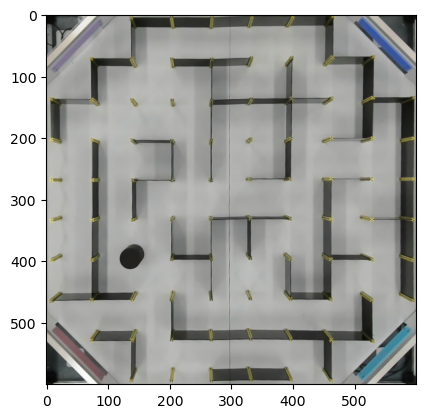

In [67]:
# Task 1.1 (1 mark): Display the occupancy map
image_file = "pic001.jpg"
image = load_and_crop_image(image_file)

plt.imshow(image)


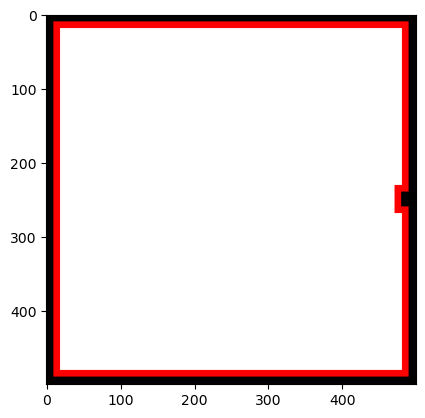

In [128]:
# Task 1.2 (3 Marks): Process occupancy map add and display configuration space
# Made function to allow calling for each of the tasks to prevent code from reusing the same variables that have already been initialised
def gen_occupancy_map():
  image = cv2.imread(image_file)
  kernel = np.ones((unsafe_kernel_size, unsafe_kernel_size), np.uint8) # TODO: Use this kernel to generate un_safe area
  # Set Black Pixel thresholds
  lowerBlack = np.array([0, 0, 0])
  upperBlack = np.array([80, 80, 80])
  # Mask and and dilate the black pixels
  mask = cv2.inRange(image, lowerBlack, upperBlack)
  dilate = cv2.dilate(mask, kernel, iterations=unsafe_iterations)
  # Create border by subtracting the mask from the dilate
  border = cv2.subtract(dilate, mask)
  image_copy = image.copy()
  # Set to red in BGR
  image_copy[border != 0] = [0, 0, 255]
  # Convert to RGB
  image_final = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
  # Save configuration space as an image
  cv2.imwrite('sample_config_map.png', image_copy)
  return image_final

image_final = gen_occupancy_map()
# Display resulting image
plt.imshow(image_final)
plt.show()

# Task 2 - Graph Class (0 marks total)

NOTE: This is slightly different to the graph in lab 07. x,y variables have been added to the node object.

In [69]:
# Task 2.1 (0 marks):  Complete the graph class

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y

    def get_point(self):
        return (self.x,self.y)

    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        self.nodes[node_id] = Node(node_id, x, y)
        self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight):
        self.edges[node_id1][node_id2] = weight
        self.edges[node_id2][node_id1] = weight

    def remove_edge(self, node_id1, node_id2):
        if node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
        if node_id1 in self.edges[node_id2]:
            del self.edges[node_id2][node_id1]

    def get_nodes(self):
        return list(self.nodes.values())

    def get_edge_weight(self, node_id1, node_id2):
        return self.edges[node_id1].get(node_id2)


In [70]:
# Graph Drawing Helper Function written by Claude

def draw_graph(image, graph, path=None, label_nodes=None, path_color='#0000ff'):
  image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  fig, ax = plt.subplots()
  ax.imshow(image_rgb)

  # Edges: dark green (0, 125, 0), width 1
  drawn = set()
  for node_id1, neighbours in graph.edges.items():
    for node_id2 in neighbours:
      key = tuple(sorted((node_id1, node_id2)))
      if key in drawn:
        continue
      drawn.add(key)
      x1, y1 = graph.nodes[node_id1].get_point()
      x2, y2 = graph.nodes[node_id2].get_point()
      ax.plot([x1, x2], [y1, y2], color=(0 / 255, 125 / 255, 0 / 255), linewidth=1, zorder=2)

  # Nodes: light green (0, 255, 0), radius 3
  for node in graph.get_nodes():
      ax.add_patch(plt.Circle((node.x, node.y), radius=3, color=(0 / 255, 255 / 255, 0 / 255), zorder=3))

  # Solved path, drawn on top
  if path:
      for i in range(len(path) - 1):
          x1, y1 = graph.nodes[path[i]].get_point()
          x2, y2 = graph.nodes[path[i + 1]].get_point()
          ax.plot([x1, x2], [y1, y2], color=path_color, linewidth=2, zorder=4)

  # Labels for specific nodes (e.g. first/last, start/goal)
  if label_nodes:
      for node_id in label_nodes:
          node = graph.nodes[node_id]
          ax.text(node.x, node.y, str(node_id), color='lime', fontsize=9, fontweight='bold', zorder=5)

  plt.show()

# Task 3 - BFS (8 marks total)

In [ ]:
# This is a useful function that you may choose to implement and use
# It looks through the image to see if the path is clear between one coordinate to the next
# Returns True or False
def wall_between_nodes(image, x1, y1, x2, y2):
    """
    Determine whether a maze wall exists between two neighbouring
    grid nodes.

    Returns:
        True  -> wall detected
        False -> no wall detected
    """
    # Convert image to BGR if necessary
    image_bgr = image
    # Red wall detection
    b, g, r = cv2.split(image_bgr)
    red_mask = ((r > 150) & (r > g * 1.4) & (r > b * 1.4))
    # Dark/black wall detection
    dark_mask = ((b < 80) & (g < 80) & (r < 80))
    wall_mask = np.uint8(red_mask | dark_mask) * 255
    # ---------------------------------------------------------
    # Sample a strip around the line between the two nodes
    # ---------------------------------------------------------
    x1 = float(x1)
    y1 = float(y1)
    x2 = float(x2)
    y2 = float(y2)
    dx = x2 - x1
    dy = y2 - y1
    length = math.hypot(dx, dy)
    if length == 0:
        return False
    # Unit vector along the edge
    ux = dx / length
    uy = dy / length
    # Perpendicular unit vector
    px = -uy
    py = ux
    # Width of area examined around the potential wall
    half_width = 5
    # Ignore the areas immediately surrounding the nodes
    start_t = 0.15
    end_t = 0.85
    wall_pixels = 0
    total_pixels = 0
    for t in np.linspace(start_t, end_t, 40):
        # Point along the edge
        cx = x1 + t * dx
        cy = y1 + t * dy
        for offset in np.linspace(-half_width, half_width, 11):
            x = int(round(cx + px * offset))
            y = int(round(cy + py * offset))
            # Bounds check
            if (0 <= y < wall_mask.shape[0] and 0 <= x < wall_mask.shape[1]):
                total_pixels += 1
                if wall_mask[y, x] > 0:
                    wall_pixels += 1
    if total_pixels == 0:
        return False
    wall_ratio = wall_pixels / total_pixels
    # Threshold can be tuned
    return wall_ratio > 0.5

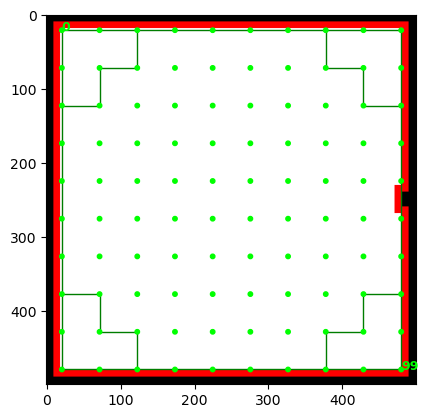

In [129]:
# Task 3.1 (4 marks): Generate a grid of nodes and connect the edges
image_file = "map.png"
bfs_image = gen_occupancy_map()
# Convert image to BGR
bfs_image = cv2.cvtColor(bfs_image, cv2.COLOR_RGB2BGR)

bfs_graph = Graph()
node_id = 0

# Buffer from outer walls, can be changed to suit different types
buffer = -5
# Find distance between nodes and create
height, width, channels = bfs_image.shape
buffer_height = height - 2*buffer
buffer_width = width - 2*buffer
x_spacing = buffer_width / (bfs_n)
y_spacing = buffer_height / (bfs_n)

xs = [x_spacing * (col + 0.5) + buffer for col in range(bfs_n)]
ys = [y_spacing * (row + 0.5) + buffer for row in range(bfs_n)]

# Add Nodes
for i in range(bfs_n):
  for j in range(bfs_n):
    bfs_graph.add_node(node_id, xs[j], ys[i])
    node_id += 1

node_id = 0
# Add Edges
for i in range(bfs_n):
  for j in range(bfs_n):
    x1, y1 = bfs_graph.nodes[node_id].get_point()
    if j < bfs_n - 1:
      right_id = node_id + 1
      x2, y2 = bfs_graph.nodes[right_id].get_point()
      if wall_between_nodes(bfs_image, x1, y1, x2, y2):
        bfs_graph.add_edge(node_id, right_id, 1)

    if i < bfs_n - 1:
      down_id = node_id + bfs_n
      x2, y2 = bfs_graph.nodes[down_id].get_point()
      if wall_between_nodes(bfs_image, x1, y1, x2, y2):
        bfs_graph.add_edge(node_id, down_id, 1)

    node_id += 1

# Add in edges that are always constant
for col in range(bfs_n - 1):
  bfs_graph.add_edge(col, col + 1, 1)
for row in range(bfs_n - 1):
  bfs_graph.add_edge(row * bfs_n, (row + 1) * bfs_n,1)
bottom_row = (bfs_n - 1) * bfs_n
for col in range(bfs_n - 1):
    bfs_graph.add_edge(bottom_row + col, bottom_row + col + 1, 1)
for row in range(bfs_n - 1):
    bfs_graph.add_edge(row * bfs_n + (bfs_n - 1), (row + 1) * bfs_n + (bfs_n - 1), 1)

# Corner edges of maze
bfs_graph.add_edge(2, 12, 1)
bfs_graph.add_edge(11, 12, 1)
bfs_graph.add_edge(11, 21, 1)
bfs_graph.add_edge(20, 21, 1)

bfs_graph.add_edge(70, 71, 1)
bfs_graph.add_edge(71, 81, 1)
bfs_graph.add_edge(81, 82, 1)
bfs_graph.add_edge(82, 92, 1)

bfs_graph.add_edge(7, 17, 1)
bfs_graph.add_edge(17, 18, 1)
bfs_graph.add_edge(18, 28, 1)
bfs_graph.add_edge(28, 29, 1)

bfs_graph.add_edge(78, 79, 1)
bfs_graph.add_edge(78, 88, 1)
bfs_graph.add_edge(87, 88, 1)
bfs_graph.add_edge(87, 97, 1)

# print(bfs_image.shape)
# for i in range(len(bfs_graph.get_nodes())):
#   print(bfs_graph.nodes[i].get_point())
# Display Resulting Image
draw_graph(bfs_image, bfs_graph, label_nodes=[0, bfs_n * bfs_n - 1])

In [103]:
def build_cell_graph(node_graph, num_cells=9):
    """
    Convert a 10x10 node/intersection graph into a
    9x9 cell graph.

    Each cell becomes a node in the new graph.

    Cell numbering:
        0   1   2   ...  8
        9  10  11   ... 17
       18  19  20   ... 26
       ...
       72  73  74   ... 80
    """

    cell_graph = Graph()

    # --------------------------------------------------
    # Create the 81 cell nodes
    # --------------------------------------------------

    for row in range(num_cells):
        for col in range(num_cells):

            cell_id = row * num_cells + col

            # Four corner node IDs
            top_left = row * (num_cells + 1) + col
            top_right = top_left + 1
            bottom_left = top_left + (num_cells + 1)
            bottom_right = bottom_left + 1

            # Get coordinates
            x1, y1 = node_graph.nodes[top_left].get_point()
            x2, y2 = node_graph.nodes[top_right].get_point()
            x3, y3 = node_graph.nodes[bottom_left].get_point()
            x4, y4 = node_graph.nodes[bottom_right].get_point()

            # Centre of cell
            centre_x = (x1 + x2 + x3 + x4) / 4
            centre_y = (y1 + y2 + y3 + y4) / 4

            cell_graph.add_node(
                cell_id,
                centre_x,
                centre_y
            )

    # --------------------------------------------------
    # Add connections between cells
    # --------------------------------------------------

    for row in range(num_cells):
        for col in range(num_cells):

            cell_id = row * num_cells + col

            # ------------------------------------------
            # Move RIGHT
            # ------------------------------------------

            if col < num_cells - 1:

                right_cell = cell_id + 1

                # Shared boundary:
                #
                #   top_right
                #       |
                #       |
                #   bottom_right
                #

                top_right = row * (num_cells + 1) + col + 1
                bottom_right = top_right + (num_cells + 1)

                # If the node graph contains this edge,
                # there is NO wall.
                if (
                    bottom_right in node_graph.edges[top_right]
                ):
                    cell_graph.add_edge(
                        cell_id,
                        right_cell,
                        1
                    )

            # ------------------------------------------
            # Move DOWN
            # ------------------------------------------

            if row < num_cells - 1:

                down_cell = cell_id + num_cells

                # Shared boundary:
                #
                # bottom_left ---- bottom_right
                #

                bottom_left = (
                    (row + 1) * (num_cells + 1) + col
                )

                bottom_right = bottom_left + 1

                # If the node graph contains this edge,
                # there is NO wall.
                if (
                    bottom_right in node_graph.edges[bottom_left]
                ):
                    cell_graph.add_edge(
                        cell_id,
                        down_cell,
                        1
                    )

    return cell_graph

In [107]:
# Task 3.2 (4 marks): Implement BFS

# Returns an array of nodes in order of which nodes are visited next.
# ie. [0, 10, 20, 30, 40, 50, 60, 70, 71, 72, 73, 74, 75, 76, 77, 78, 88, 98, 99]
def bfs(graph, start_node_id, end_node_id):
    # Check for one node graph
    if start_node_id == end_node_id:
        path = [start_node_id]
        return path

    # Create queue with start node as first in queue
    q = deque()
    visited = {}
    # Append nodes to queue
    q.append(start_node_id)
    # Use visited to track where each node has been visited from
    visited[start_node_id] = None


    # Iterate through graph
    while q:
        current_node = q.popleft()
        # Climb through variable 'visited' to generate BFS path
        if current_node == end_node_id:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = visited[current_node]
            # Reverse list and return
            return path[::-1]
        # Iterate through neighbour nodes and check if neighbour node has been visited
        for neighbour_node in graph.edges[current_node]:
            if neighbour_node not in visited:
                visited[neighbour_node] = current_node
                q.append(neighbour_node)


Cell path: None
Path: None


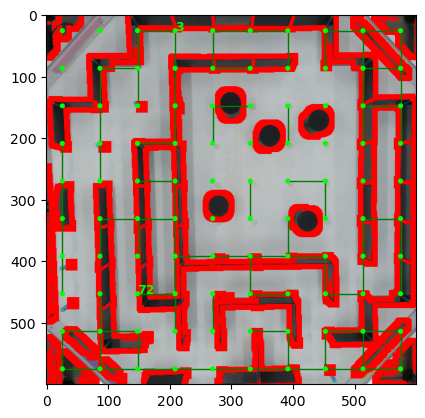

In [109]:
# Task 3.2: Implement BFS continued
# Image initialisation
bfs_image = gen_occupancy_map()
# Convert image to BGR
bfs_image = cv2.cvtColor(bfs_image, cv2.COLOR_RGB2BGR)

# Run BFS and display the output
bfs_start_cell = 3
bfs_end_cell = 72
cell_graph = build_cell_graph(bfs_graph)

path = bfs(
    cell_graph,
    bfs_start_cell,
    bfs_end_cell
)

print("Cell path:", path)

# Display the resulting image
print(f"Path: {path}")

draw_graph(bfs_image, bfs_graph, path, [bfs_start_node, bfs_end_node])